In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

Amostras foram obtidas de 3 máquinas de envase de perfume, conforme exibido a seguir. \
m1 = 150, 151, 152, 152, 151, 150 \
m2 = 153, 152, 148, 151, 149, 152 \
m3 = 156, 154, 155, 156, 157, 155 \
Com base nessas amostras, é correto afirmar que as 3 máquinas estão operando de forma idêntica, ou seja, produzindo perfumes com a mesma média? Nível de confiança: 95%.

H0: μ1 = μ2 = μ3 \
Ha: Médias não são iguais

In [10]:
m1 = [150, 151, 152, 152, 151, 150]
m2 = [153, 152, 148, 151, 149, 152]
m3 = [156, 154, 155, 156, 157, 155]

In [11]:
stats.f_oneway(m1, m2, m3) # 1° -> Fcal 2° -> p-value

F_onewayResult(statistic=np.float64(22.264705882352935), pvalue=np.float64(3.2374085509077445e-05))

Resposta: Como pvalue < 0.05, rejeitamos a hipotese nula. As médias não são iguais

É possível também obter a solução deste problema usando a biblioteca statsmodels. Vejamos como proceder.

In [12]:
import statsmodels.stats.oneway as oneway
oneway.anova_oneway([m1, m2, m3], use_var='equal')

<class 'statsmodels.stats.base.HolderTuple'>
statistic = np.float64(22.264705882352892)
pvalue = np.float64(3.237408550907782e-05)
df = (2.0, np.float64(15.0))
df_num = 2.0
df_denom = np.float64(15.0)
nobs_t = np.float64(18.0)
n_groups = 3
means = array([151.        , 150.83333333, 155.5       ])
nobs = array([6., 6., 6.])
vars_ = array([0.8       , 3.76666667, 1.1       ])
use_var = 'equal'
welch_correction = True
tuple = (np.float64(22.264705882352892), np.float64(3.237408550907782e-05))

As duas opções produzem resultados idênticos, porém o statsmodels provê um resultado mais detalhado.

### Exercício 1: MPG
Usaremos o dataset mpg (miles per galon) do seaborn. Queremos descobrir se carros americanos, japoneses e europeus tem o mesmo consumo. Faremos um teste de hipótese com confiança de 95%.

H0: μus = μjp = μeu \
Ha: Médias não são iguais

In [13]:
df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Queremo saber se os carros japoneses, americanos e europeus tem o mesmo consumo de combustível. Para tanto, precisamos agrupar os veículos por origem e obter a média de mpg (miles per galon).

In [14]:
df.groupby('origin')['mpg'].mean()

origin
europe    27.891429
japan     30.450633
usa       20.083534
Name: mpg, dtype: float64

Vamos plotar boxplots de mpg e observar o resultado.

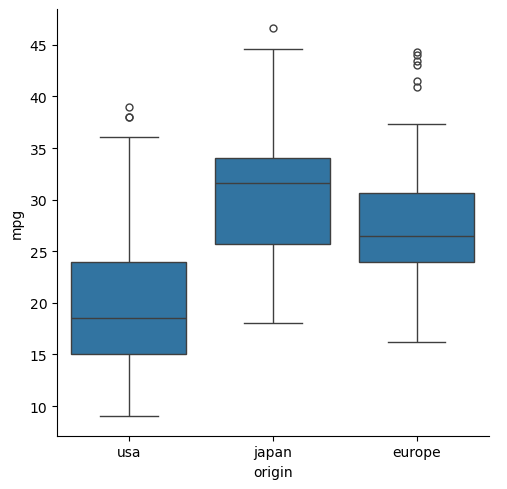

In [15]:
sns.catplot(x='origin', y='mpg', data=df, kind='box')

Analisando os resultados, está claro que os carros japoneses são os mais econômicos e os carros americanos, os mais gastões. Mas notem o número de cilindros. Os carros americanos tem, em média, muito mais cilindros que os carros europeus e japoneses. Para evitar esse viés, vamos trabalhar apenas com os veículos de 4 cilindros.

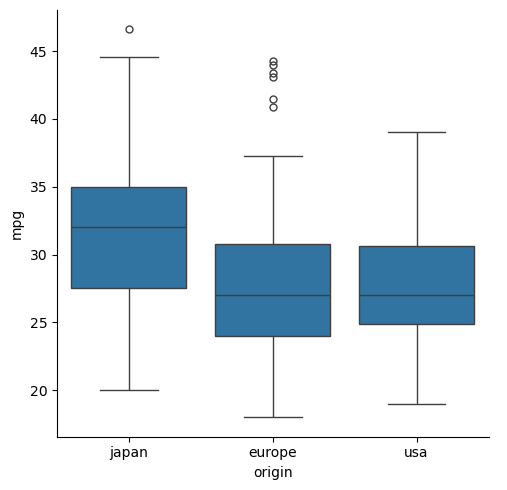

In [16]:
df2 = df[df['cylinders'] == 4]
sns.catplot(x='origin', y='mpg', data=df2, kind='box')

Ao considerar carros de 4 cilindros, ainda temos os carros japoneses como mais econômicos, porém vemos uma quase igualdade entre os carros americanos e europeus. Vamos realizar o teste ANOVA para saber se temos de fato uma diferença nas médias de consumo.

In [17]:
eu = df2[df2['origin'] == 'europe']['mpg']
jp = df2[df2['origin'] == 'japan']['mpg']
usa = df2[df2['origin'] == 'usa']['mpg']

In [18]:
stats.f_oneway(eu, jp, usa)

F_onewayResult(statistic=np.float64(9.411845545485605), pvalue=np.float64(0.00012379894210177303))

Resposta: Já que pvalue < 0.05, rejeitamos a hipótese nula, logo, temos que as médias de consumo dos carros americanos, japonese e europeus são diferentes.

### Exercício 2
Uma pediatra quer ver o efeito do consumo de fórmula (leite em pó) no ganho médio de peso mensal (em gramas) dos bebês. Por esse motivo, ela coletou dados de três grupos diferentes. O primeiro grupo é composto por crianças amamentadas exclusivamente (recebe apenas leite materno), o segundo grupo é composto por crianças que são alimentadas apenas com fórmula e o último grupo é composto por crianças amamentadas e com fórmula. Esses dados são os seguintes.

leite_materno = [794.1, 716.9, 993. , 724.7, 760.9, 908.2, 659.3 , 690.8, 768.7, 717.3 , 630.7, 729.5, 714.1, 810.3, 583.5, 679.9, 865.1]

formula = [ 898.8, 881.2, 940.2, 966.2, 957.5, 1061.7, 1046.2, 980.4, 895.6, 919.7, 1074.1, 952.5, 796.3, 859.6, 871.1 , 1047.5, 919.1 , 1160.5, 996.9]

ambos = [976.4, 656.4, 861.2, 706.8, 718.5, 717.1, 759.8, 894.6, 867.6, 805.6, 765.4, 800.3, 789.9, 875.3, 740. , 799.4, 790.3, 795.2 , 823.6, 818.7, 926.8, 791.7, 948.3]

Realize um teste de hipótese e informe se há diferença no peso médio das crianças desses 3 grupos. Nível de cofiança de 95%.

H0: μleite = μfor = μambos \
Ha: Médias não são iguais

In [19]:
leite_materno = [794.1, 716.9, 993. , 724.7, 760.9, 908.2, 659.3 , 690.8, 768.7, 717.3 , 630.7, 729.5, 714.1, 810.3, 583.5, 679.9, 865.1]

formula = [ 898.8, 881.2, 940.2, 966.2, 957.5, 1061.7, 1046.2, 980.4, 895.6, 919.7, 1074.1, 952.5, 796.3, 859.6, 871.1 , 1047.5, 919.1 , 1160.5, 996.9]

ambos = [976.4, 656.4, 861.2, 706.8, 718.5, 717.1, 759.8, 894.6, 867.6, 805.6, 765.4, 800.3, 789.9, 875.3, 740. , 799.4, 790.3, 795.2 , 823.6, 818.7, 926.8, 791.7, 948.3]

In [20]:
stats.f_oneway(leite_materno, formula, ambos)

F_onewayResult(statistic=np.float64(26.70125185753797), pvalue=np.float64(7.186235502885776e-09))

Resposta: Já que pvalue < 0.05, rejeitamos a hipótese nula, logo, temos que há diferença no peso médio das crianças dos 3 grupos

Realizaremos um teste de Tuckey para entender melhor o resultado e saber qual(is) métodos é(são) melhor(res).

In [21]:
from scipy.stats import tukey_hsd

resultado = tukey_hsd(leite_materno, formula, ambos)

print(resultado)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)   -209.392     0.000  -281.434  -137.351
 (0 - 2)    -60.129     0.100  -129.149     8.891
 (1 - 0)    209.392     0.000   137.351   281.434
 (1 - 2)    149.264     0.000    82.365   216.162
 (2 - 0)     60.129     0.100    -8.891   129.149
 (2 - 1)   -149.264     0.000  -216.162   -82.365



C:\Users\jpgto\AppData\Local\Temp\ipykernel_11664\280436462.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados, labels=['Leite Materno', 'Formula', 'Ambos']);


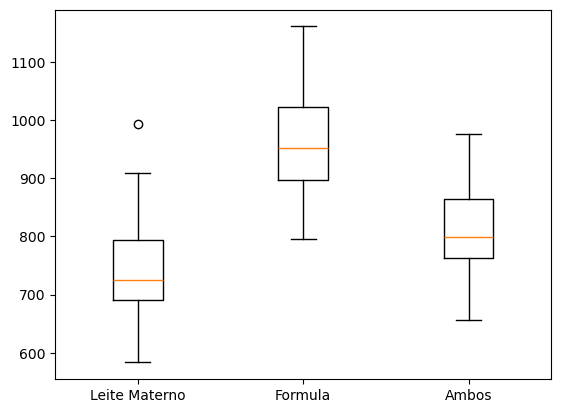

In [22]:
dados = [leite_materno, formula, ambos]

plt.boxplot(dados, labels=['Leite Materno', 'Formula', 'Ambos']);


Conclusão: Leite materno e Ambos resultam no mesmo peso médio. O uso da fórmula resulta no aumento do peso médio do bebê.

### Exercício 3
Utilizando o dataset 'bike_sharing_hour', realize um teste de hípoteses que verifique se a quantidade média de aluguéis de bicicletas muda de acordo com as estações do ano. Faça o teste com confiança de 95%. 

Se a qauntidade média for diferente, realize o teste de Tukey e determine qual estação tem mais ou menos locações. Finalente, plote um boxplot dos aluguéis das 4 estações do ano e disuta os resultados.

Tente inferir qual estação do ano está associada aos números 1-4, levando em conta que os dados foram coletados num país frio do hemisfério norte.

H0: μest1 = μest2 = μest3 = μest4 \
Ha: Médias não são iguais

In [23]:
df = pd.read_csv('bike_sharing_hour.csv')
df['dteday'] = pd.to_datetime(df['dteday'])
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [24]:
prim = df[df['season'] == 1]['cnt']
seg = df[df['season'] == 2]['cnt']
terc = df[df['season'] == 3]['cnt']
quart = df[df['season'] == 4]['cnt']

stats.f_oneway(prim, seg, terc, quart)

F_onewayResult(statistic=np.float64(409.1810372630525), pvalue=np.float64(7.40107139971279e-257))

Conclusão: Já que pvalue < 0.05, rejeitamos a hipótese nula. Logo, as médias das estações são diferentes

In [25]:
res = tukey_hsd(prim, seg, terc, quart)
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -97.230     0.000  -106.917   -87.542
 (0 - 2)   -124.902     0.000  -134.543  -115.260
 (0 - 3)    -87.754     0.000   -97.541   -77.968
 (1 - 0)     97.230     0.000    87.542   106.917
 (1 - 2)    -27.672     0.000   -37.219   -18.125
 (1 - 3)      9.475     0.058    -0.218    19.169
 (2 - 0)    124.902     0.000   115.260   134.543
 (2 - 1)     27.672     0.000    18.125    37.219
 (2 - 3)     37.147     0.000    27.500    46.795
 (3 - 0)     87.754     0.000    77.968    97.541
 (3 - 1)     -9.475     0.058   -19.169     0.218
 (3 - 2)    -37.147     0.000   -46.795   -27.500



C:\Users\jpgto\AppData\Local\Temp\ipykernel_11664\3168728465.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados2, labels=['Inverno(Prim)', 'Primavera(Seg)', 'Verão(Terc)', 'Outono(Quart)']);


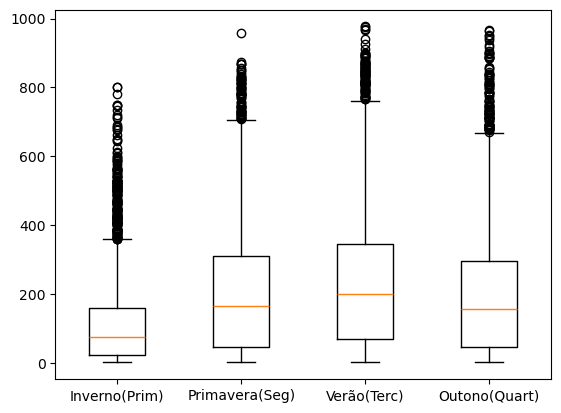

In [28]:
dados2 = [prim, seg, terc, quart]

plt.boxplot(dados2, labels=['Inverno(Prim)', 'Primavera(Seg)', 'Verão(Terc)', 'Outono(Quart)']);


Conclusão: Baseando-se no teste de Tukey, temos que as estações 2 e 4 tem médias de locação iguais. Baseando-se no boxplot, temos que a primeita estação (indice 0) tem menos locações, enquanto a terceira estação (indice 2) tem mais locações. Assim, pode-se inferir que a primeira locação é a da estação mais fria, ou seja Inverno(0), seguindo de Primavera(1), Verão(2), que possui mais locações, e por fim, Outono(3).